In [74]:
import sys
sys.path.insert(1, '..')

import os, yaml, pickle

from physics.simulation import mcfm, msq
from physics.hzz import zpair, zz4l
from physics.hstar import c6
from datasets import coefficient
from models import rolypoly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist
import pandas as pd

import torch
from lightning import Trainer

In [75]:
OUTPUT_DIR = '../jobs/rolypoly/refactor-eight-SBI-3M/coeff_4/'
SCALER_FILE_X = 'scaler_X.pkl'
SCALER_FILE_Y = 'scaler_y.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

checkpoint_epoch = '187'
checkpoint_loss = '0.03'

CHECKPOINT = f'checkpoint-rolypoly-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION_NO = 3
LIGHTNING_DIR = f'lightning_logs/version_{VERSION_NO}'

COMPONENT = msq.Component.SBI
COMPONENT_FILE = msq.Component.BKG

FEATURES = ['cth_star', 'cth_1', 'cth_2', 'phi', 'phi_1', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']
FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']


COEFFICIENT_INDEX = 4
SAMPLE_SIZE = 150000
BATCH_SIZE = 64
SEED = 42

In [76]:
with open(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'hparams.yaml'), 'r') as f:
    params = yaml.load(f, Loader=yaml.CLoader)

In [77]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [78]:
sample = mcfm.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=250000).reweight(COMPONENT_FILE, COMPONENT)
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
mandelstam = zz4l.MandelstamVariables()
angles = zz4l.AngularVariables()
fourlepton = zz4l.FourLeptonSystem()
lepton_momenta = zz4l.LeptonMomenta()

sample = sample.calculate(z_cand).filter(z_masses).calculate(mandelstam).calculate(angles).calculate(fourlepton).calculate(lepton_momenta)

1.4027402816655274


In [79]:
c6_mod = c6.Modifier(baseline=COMPONENT, events=sample, c6_values=[-5,-1,0,1,5]) if COMPONENT!=msq.Component.INT else c6.Modifier(baseline=COMPONENT, events=sample, c6_values=[-5,0,5])
coefficient = c6_mod.coefficients[:,COEFFICIENT_INDEX]

unweighted_indices = sample.weights.sample(n=SAMPLE_SIZE, replace=True, weights=np.ones_like(sample.weights), random_state=SEED).index
        
X = sample.kinematics[FEATURES].to_numpy()[unweighted_indices]

with open(os.path.join(OUTPUT_DIR, SCALER_FILE_X), 'rb') as f:
    scaler_X = pickle.load(f)

X = torch.tensor(scaler_X.transform(X), dtype=torch.float32).cpu()
y = coefficient[unweighted_indices]

In [80]:
print(np.median(y))

9.072680462365349e-08


In [81]:
loaded_model = rolypoly.ROLYPOLY.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [82]:
predictions = loaded_model(X).detach().view(-1).numpy()

In [83]:
with open(os.path.join(OUTPUT_DIR, SCALER_FILE_Y), 'rb') as f:
    scaler_y = pickle.load(f)

predictions = scaler_y.inverse_transform(predictions[:,np.newaxis]).flatten()

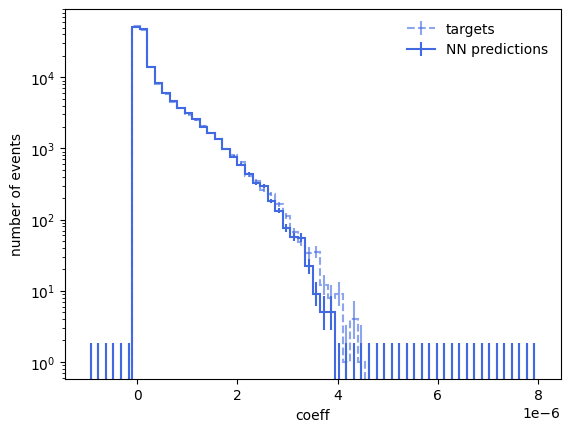

In [84]:
BINS = 60

bounds = [-2e-2,2e-2]
bounds = [-1.5e-3,2e-3]
bounds = [-8e-6,1e-6]
bounds = [-1e-6,8e-6]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
#y[y>=0] = -y[y>=0]
h_targets_train.fill(y)

h_targets_train.plot(color='royalblue', linestyle='--', label='targets', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions')

plt.xlabel(f'coeff')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend(frameon=False)

plt.show()

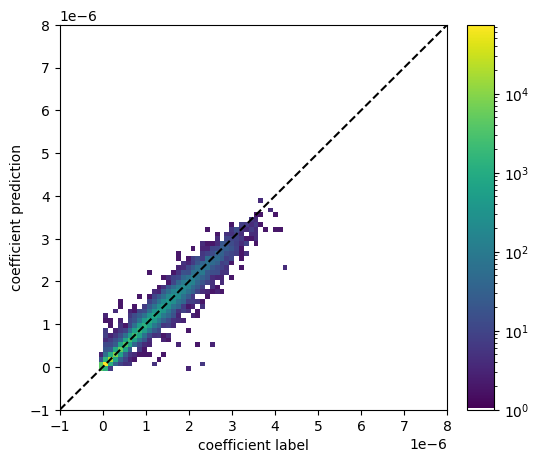

In [85]:
BINS=80

bounds = [-2e-2,2e-2]
bounds = [-1.5e-3,2e-3]
bounds = [-8e-6,1e-6]
bounds = [-1e-6,8e-6]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='coefficient label'),
    hist.axis.Regular(BINS, *bounds, name='coefficient prediction')
)

h_calibration_train.fill(y, predictions)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_train.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')


plt.show()

[8.5016376e-09 3.4959243e-08 9.9136784e-08 1.8516315e-07 2.6916851e-07
 3.5238705e-07 4.3524318e-07 5.1802175e-07 5.9816250e-07 6.8113167e-07
 7.6584632e-07 8.4587964e-07 9.1904258e-07 1.0071615e-06 1.0837877e-06
 1.1631507e-06 1.2338897e-06 1.3218776e-06 1.3915331e-06 1.4663140e-06
 1.5554333e-06 1.6266584e-06 1.7075999e-06 1.7711262e-06 1.8575117e-06
 1.9135668e-06 1.9941861e-06 2.0999967e-06 2.0939633e-06 2.2246795e-06
 2.2757854e-06 2.3766290e-06 2.4001197e-06 2.4568105e-06 2.5598829e-06
 2.5790362e-06 2.7107731e-06 2.7471713e-06 2.8586130e-06 2.9442408e-06
 2.9913906e-06 3.0183946e-06 3.0939457e-06 3.1927368e-06 3.1910420e-06
 3.3383194e-06 3.3653755e-06 3.5890650e-06 2.3713319e-06 3.5454250e-06]
[-2.10513242e-08  3.15916761e-08  9.73670151e-08  1.83179533e-07
  2.66014394e-07  3.48842411e-07  4.31127861e-07  5.14151511e-07
  5.96191917e-07  6.78369308e-07  7.61310867e-07  8.43276785e-07
  9.24732165e-07  1.00478781e-06  1.08854133e-06  1.17028805e-06
  1.25289463e-06  1.33497127e

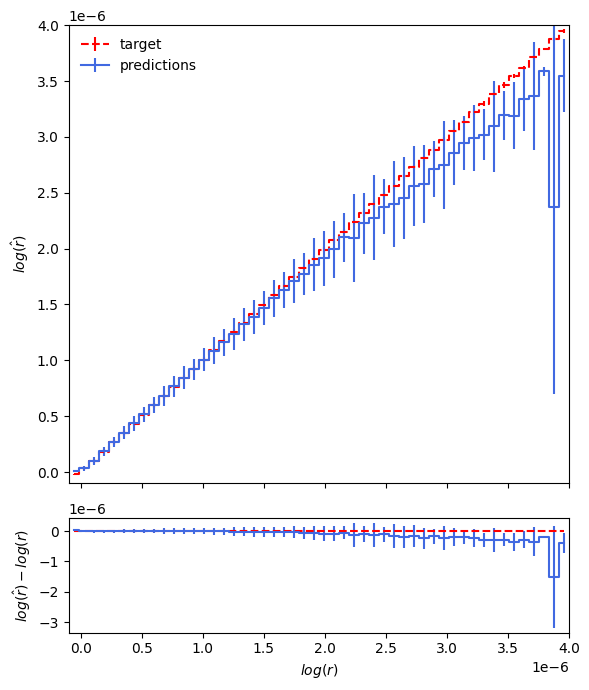

In [93]:
BINS=50

bounds = [-1e-7,4e-6]

step_size = (bounds[1]-bounds[0])/BINS

p = predictions
t = y

binned_pred = [p[np.where((t>=i*step_size+bounds[0])&(t<(i+1)*step_size+bounds[0]))] for i in range(BINS)]
average_preds = np.array([np.mean(el) for el in binned_pred])
std_dev_preds = np.array([np.std(el) for el in binned_pred])

binned_target = [t[np.where((t>=i*step_size+bounds[0])&(t<(i+1)*step_size+bounds[0]))] for i in range(BINS)]
average_targets = np.array([np.mean(el) for el in binned_target])
std_dev_targets = np.array([np.std(el) for el in binned_target])

centers = [(i+1/2)*step_size+bounds[0] for i in range(BINS)]

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, average_targets, yerr=std_dev_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax1.errorbar(centers, average_preds, yerr=std_dev_preds, drawstyle='steps-mid', color='royalblue', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$log(\hat{r})$')

ax1.legend(frameon=False)

print(average_preds)
print(average_targets)
print(average_preds/average_targets)

ax2.errorbar(centers, average_targets-average_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax2.errorbar(centers, average_preds-average_targets, yerr=(std_dev_preds**2 + std_dev_targets**2)**(1/2), drawstyle='steps-mid', color='royalblue', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$log(r)$')
ax2.set_ylabel('$log(\hat{r}) - log(r)$')

plt.tight_layout()

plt.show()

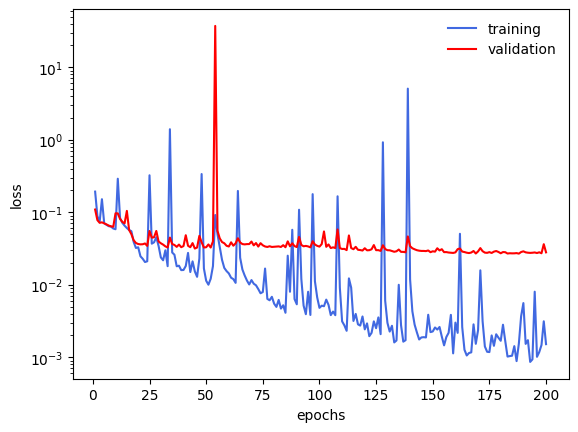

In [86]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs+1, train_loss, color='royalblue', label='training')
plt.plot(epochs+1, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.xscale('log')
plt.yscale('log')
#plt.ylim(0.055355,0.05538)
plt.legend(frameon=False)
plt.show()